In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, mean_absolute_percentage_error
from xgboost import XGBClassifier
from prophet import Prophet

df = pd.read_csv('../data/clean_df.csv', parse_dates=['InvoiceDate'])

In [12]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,3018.616737
std,1715.572666,209.338707,13.009406,14737.731040
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,348.762500
50%,15314.500000,96.000000,3.000000,898.915000
75%,16797.750000,380.000000,7.000000,2307.090000
max,18287.000000,739.000000,398.000000,608821.650000


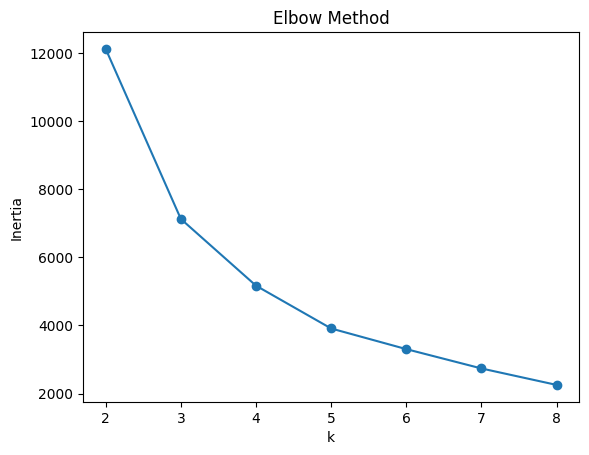

Silhouette scores: {2: 0.916, 3: 0.58, 4: 0.591, 5: 0.6, 6: 0.55, 7: 0.549, 8: 0.541}


In [16]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

inertias, sil_scores = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, km.labels_))

plt.plot(range(2,9), inertias, marker='o')
plt.title('Elbow Method'); plt.xlabel('k'); plt.ylabel('Inertia'); plt.show()
print("Silhouette scores:", dict(zip(range(2,9), [round(s,3) for s in sil_scores])))

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,463.032032,2.212212,765.244446
1,67.005728,7.307732,3009.402451
2,25.942857,103.714286,83086.079771
3,3.500000,212.500000,436835.792500


In [15]:
means = rfm.groupby('Cluster')['Monetary'].mean().sort_values(ascending=False)
labels = {means.index[0]:'Champions', means.index[1]:'Loyal',
          means.index[2]:'At Risk',   means.index[3]:'Hibernating'}
rfm['Segment'] = rfm['Cluster'].map(labels)
rfm['Segment'].value_counts()

Segment
At Risk        3841
Hibernating    1998
Loyal            35
Champions         4
Name: count, dtype: int64

In [17]:
rfm['Churned'] = (rfm['Recency'] > 90).astype(int)
X = rfm[['Recency','Frequency','Monetary']]
y = rfm['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                     eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

y_prob = xgb.predict_proba(X_test)[:,1]
print("AUC-ROC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, xgb.predict(X_test)))

AUC-ROC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       578
           1       1.00      1.00      1.00       598

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



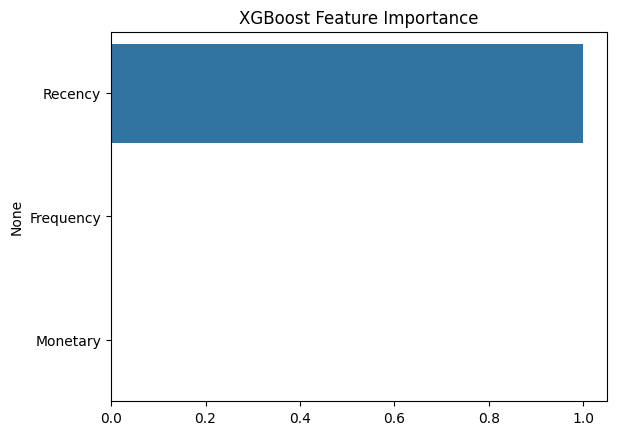

In [18]:
import seaborn as sns
importances = pd.Series(xgb.feature_importances_, index=X.columns)
sns.barplot(x=importances.values, y=importances.index)
plt.title('XGBoost Feature Importance')
plt.show()

In [19]:
rfm['ChurnProbability'] = xgb.predict_proba(X)[:,1]
rfm.to_csv('../data/rfm.csv', index=False)

13:38:38 - cmdstanpy - INFO - Chain [1] start processing
13:38:39 - cmdstanpy - INFO - Chain [1] done processing


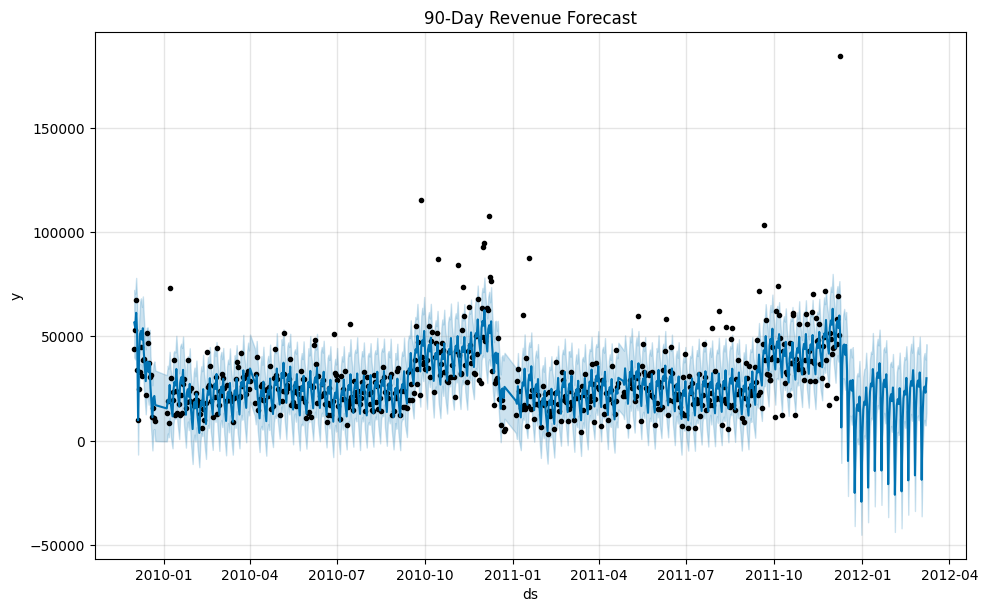

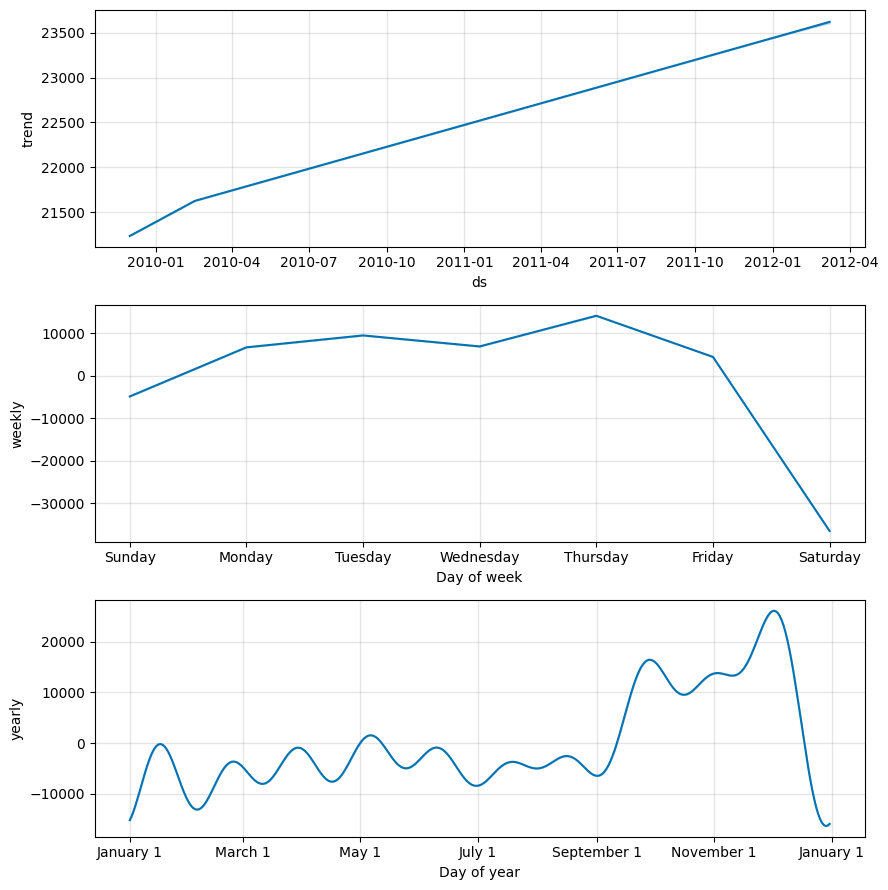

In [20]:
daily = df.resample('D', on='InvoiceDate')['TotalPrice'].sum().reset_index()
daily.columns = ['ds','y']
daily = daily[daily['y'] > 0]

model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(daily)
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

fig = model.plot(forecast)
plt.title('90-Day Revenue Forecast')
plt.show()

model.plot_components(forecast)
plt.show()

In [21]:
holdout = daily.tail(30)
merged = holdout.merge(forecast[['ds','yhat']], on='ds', how='left')
mape = mean_absolute_percentage_error(merged['y'], merged['yhat'])
print(f"MAPE: {mape:.2%}")

forecast[['ds','yhat','yhat_lower','yhat_upper']].to_csv('../data/forecast.csv', index=False)

MAPE: 31.63%


In [22]:
pr = df.groupby('StockCode').agg(
    TotalRevenue=('TotalPrice','sum'),
    SalesPrice=('Price','mean'),
    AnnualDemand=('Quantity','sum')
).reset_index().sort_values('TotalRevenue', ascending=False)

pr['CumulativePct'] = pr['TotalRevenue'].cumsum() / pr['TotalRevenue'].sum()
pr['ABC_Category'] = pr['CumulativePct'].apply(lambda p: 'A' if p<=0.7 else ('B' if p<=0.9 else 'C'))
pr['ABC_Category'].value_counts()

ABC_Category
C    3015
B     979
A     637
Name: count, dtype: int64

In [23]:
ORDERING_COST, HOLDING_RATE = 50, 0.20
pr['HoldingCost'] = pr['SalesPrice'] * HOLDING_RATE
pr['EOQ'] = np.sqrt((2*pr['AnnualDemand']*ORDERING_COST) / pr['HoldingCost'].replace(0,np.nan)).fillna(0).round(0)

pr.to_csv('../data/inventory.csv', index=False)
pr.head(10)

,StockCode,TotalRevenue,SalesPrice,AnnualDemand,CumulativePct,ABC_Category,HoldingCost,EOQ
1609,22423,286486.30,12.461071,24899,0.016146,A,2.492214,1000.0
4080,85123A,252227.81,2.870366,93697,0.030361,A,0.574073,4040.0
4058,85099B,170616.68,1.959759,94983,0.039977,A,0.391952,4923.0
2726,23843,168469.60,2.080000,80995,0.049472,A,0.416000,4412.0
4625,M,152340.57,206.440550,9803,0.058058,A,41.288110,154.0
3819,84879,127074.17,1.676403,79913,0.065219,A,0.335281,4882.0
4627,POST,126563.04,29.749070,5333,0.072352,A,5.949814,299.0
3059,47566,103880.23,4.771579,23607,0.078207,A,0.954316,1573.0
2324,23166,81416.73,1.220303,77916,0.082795,A,0.244061,5650.0
1298,22086,79594.33,2.919336,29477,0.087281,A,0.583867,2247.0
